In [ ]:
import os
import sys

# Get the absolute path to the 'src' directory
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [7]:
import pandas as pd
from data_loader import get_processed_data
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load the standardized data
df = get_processed_data()

Loading cached data from c:\Users\user\OneDrive - American University of Phnom Penh\ITEC-PARA-Chiv Vithourak\1. Courses\ITM 360\air-quality-index-forecast\src\data\beijing_aqi.csv


In [ ]:
# Transformation
import tensorflow as tf
from tensorflow.keras.layers import StringLookup, CategoryEncoding
import pandas as pd
import numpy as np

# 1. Create Lag Features
def create_lags(df, n_lags=3):
    df_n = df.copy()
    for i in range(1, n_lags + 1):
        df_n[f'pm2.5_lag_{i}'] = df_n['pm2.5'].shift(i)
    return df_n.dropna()

df_lagged = create_lags(df)

# 2. Setup TensorFlow Encoding Layers
vocab = df_lagged['cbwd'].unique().tolist()

# Layer 1: Map strings to integer IDs (e.g., "NW" -> 1)
lookup = StringLookup(vocabulary=vocab, output_mode='int')

# Layer 2: Turn IDs into One-Hot vectors
encoder = CategoryEncoding(num_tokens=len(vocab) + 1, output_mode="one_hot")

# 3. Apply the Transformation
# Convert column to tensor, then through lookup and encoder
wind_tensor = tf.constant(df_lagged['cbwd'].values)
encoded_wind = encoder(lookup(wind_tensor)).numpy()

# 4. Reconstruct the Dataframe
# Create names for the new one-hot columns
encoded_cols = [f"cbwd_{v}" for v in vocab] + ["cbwd_unknown"]
wind_df = pd.DataFrame(encoded_wind, index=df_lagged.index, columns=encoded_cols)

# Combine with numeric features and drop the original string column
df_transformed = pd.concat([df_lagged.drop(columns=['cbwd']), wind_df], axis=1)

# 5. Define Features (X) and Target (y)
X = df_transformed.drop(columns=['pm2.5'])
y = df_transformed['pm2.5']

In [7]:
# Split data (Time-series aware split)
# We don't use shuffle=True because the order of time matters!
split_idx = int(len(df_transformed) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Initialize and Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
print("Training model...")
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Training model...
Mean Absolute Error: 11.83
R2 Score: 0.95


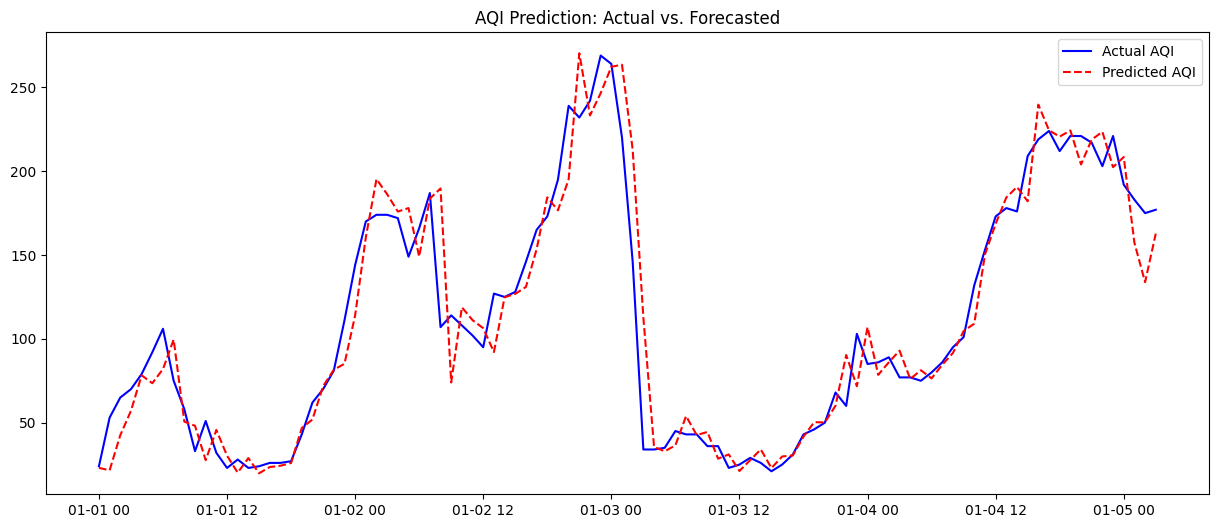

In [8]:
import matplotlib.pyplot as plt
# Visualize
plt.figure(figsize=(15, 6))
plt.plot(y_test.index[:100], y_test.values[:100], label='Actual AQI', color='blue')
plt.plot(y_test.index[:100], predictions[:100], label='Predicted AQI', color='red', linestyle='--')
plt.title('AQI Prediction: Actual vs. Forecasted')
plt.legend()
plt.show()